# Sleep Causal Investigation

Tests six mechanistic hypotheses about what drives sleep quality.

**Sleep deprivation definition**: score < 50 OR total_sleep < 4.5 h

## Sections
1. Bedtime Threshold (3 AM cliff-edge)
2. Exercise Intensity vs Sport Label
3. Stress → Bedtime Feedback Loop
4. Deep Sleep Onset Cascading (night N → night N+1)
5. Cardio vs Strength Workout Comparison
6. Steps vs Sleep (calories_consumed unavailable)

In [1]:
import sys
from pathlib import Path

# Add analysis dir to path so garmin_utils and customized modules are importable
ANALYSIS_DIR = Path(".").resolve()
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

from customized.sleep_feature_builder import build_sleep_features, CONTROLLABILITY

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
df = build_sleep_features()
print(f"Feature matrix: {df.shape[0]} nights x {df.shape[1]} columns")
print(f"Date range: {df['day'].min()} → {df['day'].max()}")

# Sleep deprivation flag (consistent with other notebooks)
df["is_deprived"] = (df["score"] < 50) | (df["total_sleep_hours"] < 4.5)
dep_rate = df["is_deprived"].mean()
print(f"Deprived nights: {df['is_deprived'].sum()} / {len(df)} ({dep_rate:.1%})")

Loading sleep data...
Loading activities...
Filtered 253 nighttime activities (22:30–04:00 window)
Building exercise features...
Loading daily summary and days summary...
Loading monitoring_hr...
Loading stress...
Loading monitoring_rr...
Loading monitoring (steps/calories)...
Computing pre-sleep HR features...
Computing pre-sleep stress features...
Computing pre-sleep RR features...
Computing pre-sleep activity features...
Building sleep architecture features...
Done. Shape: (601, 150)
Feature matrix: 601 nights x 150 columns
Date range: 2024-07-01 00:00:00 → 2026-02-21 00:00:00
Deprived nights: 104 / 601 (17.3%)


---
## Section 1: Bedtime Threshold (3 AM Cliff-Edge)

**Hypothesis**: A bedtime at or after 3:00 AM acts as a non-linear threshold — crossing it sharply increases deprivation risk beyond what continuous sleep_start_hour correlation suggests.

In [3]:
# --- 3.1 Split: before-3AM vs at/after-3AM ---
s1 = df.dropna(subset=["sleep_start_hour", "score", "is_deprived"]).copy()

before = s1[s1["is_late_bedtime"] == False]
after  = s1[s1["is_late_bedtime"] == True]

# Mann-Whitney
mw_stat, mw_p = stats.mannwhitneyu(
    before["score"].dropna(), after["score"].dropna(), alternative="greater"
)

# Rank-biserial effect size
n1, n2 = len(before["score"].dropna()), len(after["score"].dropna())
rb_r = 1 - (2 * mw_stat) / (n1 * n2)

summary = pd.DataFrame({
    "Group": ["Before 3 AM", "At / After 3 AM"],
    "n": [len(before), len(after)],
    "Mean Score": [before["score"].mean(), after["score"].mean()],
    "Deprivation Rate": [before["is_deprived"].mean(), after["is_deprived"].mean()],
})
print(summary.to_string(index=False, float_format="{:.2f}".format))
print(f"\nMann-Whitney: U={mw_stat:.0f}, p={mw_p:.4f}, rank-biserial r={rb_r:.3f}")

          Group   n  Mean Score  Deprivation Rate
    Before 3 AM 426       67.55              0.07
At / After 3 AM 140       64.95              0.27

Mann-Whitney: U=31999, p=0.0971, rank-biserial r=-0.073


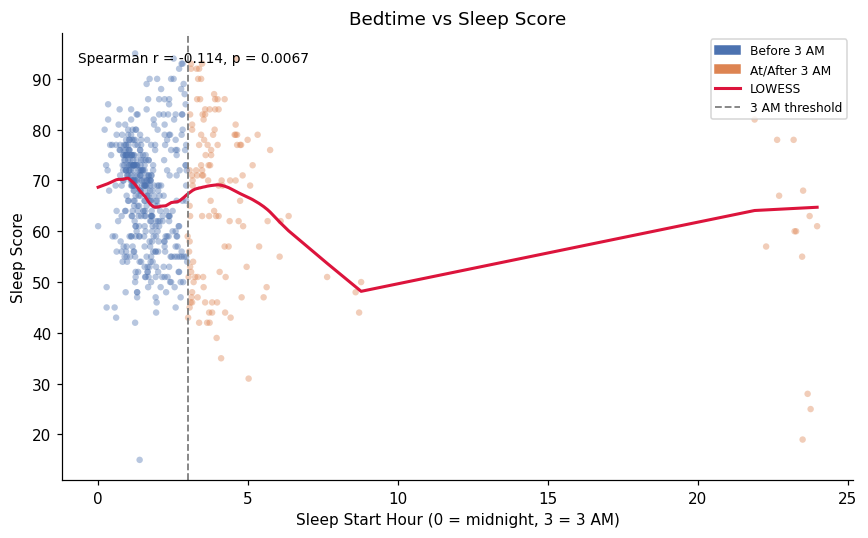

In [4]:
# --- 3.2 Scatter + LOWESS: sleep_start_hour vs score ---
s1_clean = s1.dropna(subset=["sleep_start_hour", "score"])
r_sp, p_sp = stats.spearmanr(s1_clean["sleep_start_hour"], s1_clean["score"])

fig, ax = plt.subplots(figsize=(8, 5))
colors = s1_clean["is_late_bedtime"].map({False: "#4C72B0", True: "#DD8452"})
ax.scatter(s1_clean["sleep_start_hour"], s1_clean["score"],
           c=colors, alpha=0.4, s=18, linewidths=0)

# LOWESS
xy = s1_clean[["sleep_start_hour", "score"]].sort_values("sleep_start_hour")
smoothed = lowess(xy["score"], xy["sleep_start_hour"], frac=0.35)
ax.plot(smoothed[:, 0], smoothed[:, 1], color="crimson", lw=2, label="LOWESS")

ax.axvline(3.0, color="gray", lw=1.2, linestyle="--", label="3 AM threshold")
ax.set_xlabel("Sleep Start Hour (0 = midnight, 3 = 3 AM)")
ax.set_ylabel("Sleep Score")
ax.set_title("Bedtime vs Sleep Score")
ax.legend(fontsize=9)
ax.text(0.02, 0.96, f"Spearman r = {r_sp:.3f}, p = {p_sp:.4f}",
        transform=ax.transAxes, fontsize=9, va="top")

# Colour legend patches
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#4C72B0", label="Before 3 AM"),
    Patch(color="#DD8452", label="At/After 3 AM"),
    plt.Line2D([0],[0], color="crimson", lw=2, label="LOWESS"),
    plt.Line2D([0],[0], color="gray", lw=1.2, ls="--", label="3 AM threshold"),
], fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

---
## Section 2: Exercise Intensity vs Sport Label

**Hypothesis**: Raw vigorous-zone ratio (hrz4+hrz5 / total workout time) explains more sleep score variance than the coarser sport label.

In [5]:
# --- 4.1 Correlation: vigorous_ratio vs score; compare to sport-label correlation ---
s2 = df.dropna(subset=["same_day_vigorous_ratio", "score"]).copy()

r_vig, p_vig = stats.spearmanr(s2["same_day_vigorous_ratio"], s2["score"])

# Sport-label encoded (ordinal: cardio=3, mixed=2, strength=1, other=0, NaN=NaN)
sport_map = {"cardio": 3, "mixed": 2, "strength": 1, "other": 0}
s2_sport = df.dropna(subset=["sport_category", "score"]).copy()
s2_sport["sport_encoded"] = s2_sport["sport_category"].map(sport_map)
r_sport, p_sport = stats.spearmanr(s2_sport["sport_encoded"], s2_sport["score"])

print("Spearman correlation with next-night sleep score (exercise days only):")
print(f"  same_day_vigorous_ratio : r = {r_vig:.3f}, p = {p_vig:.4f}  (n={len(s2)})")
print(f"  sport_category (encoded): r = {r_sport:.3f}, p = {p_sport:.4f}  (n={len(s2_sport)})")

Spearman correlation with next-night sleep score (exercise days only):
  same_day_vigorous_ratio : r = 0.071, p = 0.2560  (n=257)
  sport_category (encoded): r = -0.031, p = 0.6153  (n=257)


/Users/yinhsu/Documents/side_project/garmin_data_analyze/.venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


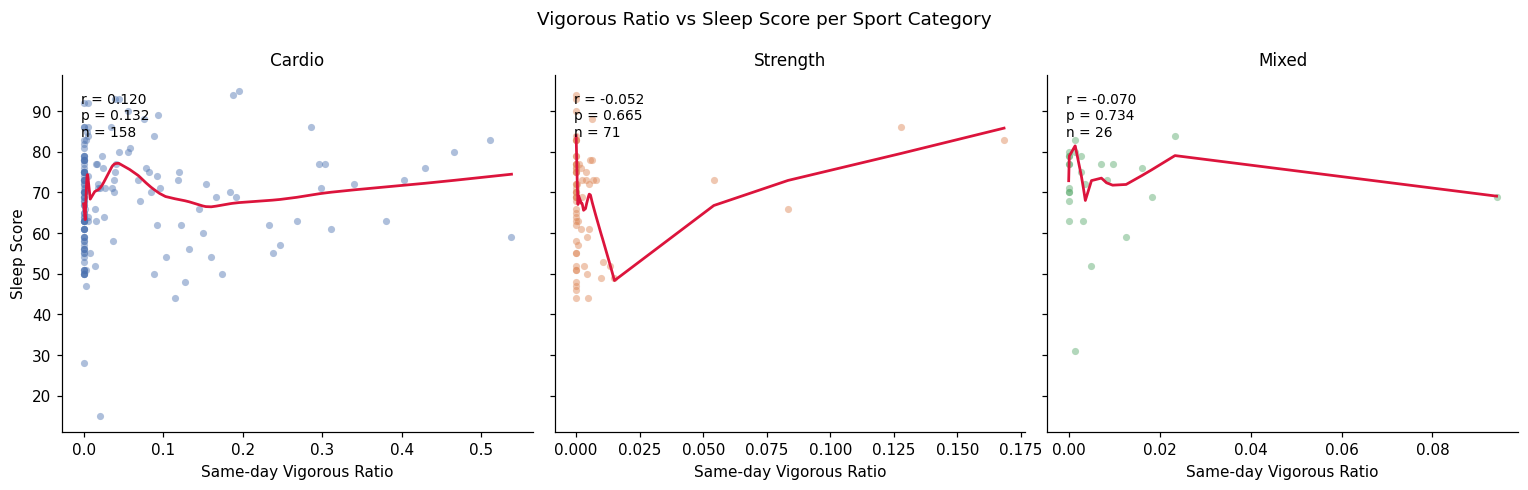

In [6]:
# --- 4.2 Scatter per sport category with LOWESS ---
cats = ["cardio", "strength", "mixed"]
colors_sport = {"cardio": "#4C72B0", "strength": "#DD8452", "mixed": "#55A868"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, cat in zip(axes, cats):
    sub = df[(df["sport_category"] == cat)].dropna(subset=["same_day_vigorous_ratio", "score"])
    ax.scatter(sub["same_day_vigorous_ratio"], sub["score"],
               alpha=0.45, s=22, color=colors_sport[cat], linewidths=0)
    if len(sub) >= 5:
        r_c, p_c = stats.spearmanr(sub["same_day_vigorous_ratio"], sub["score"])
        if len(sub) >= 10:
            sm = lowess(sub["score"].values,
                        sub["same_day_vigorous_ratio"].values, frac=0.5)
            ax.plot(sm[:, 0], sm[:, 1], color="crimson", lw=1.8)
        ax.text(0.04, 0.95, f"r = {r_c:.3f}\np = {p_c:.3f}\nn = {len(sub)}",
                transform=ax.transAxes, fontsize=9, va="top")
    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel("Same-day Vigorous Ratio")

axes[0].set_ylabel("Sleep Score")
fig.suptitle("Vigorous Ratio vs Sleep Score per Sport Category", fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 3: Stress → Bedtime Feedback Loop

**Hypothesis**: High evening stress (pre_sleep_stress_avg_4h) causes later bedtimes, independently of whether exercise occurred.

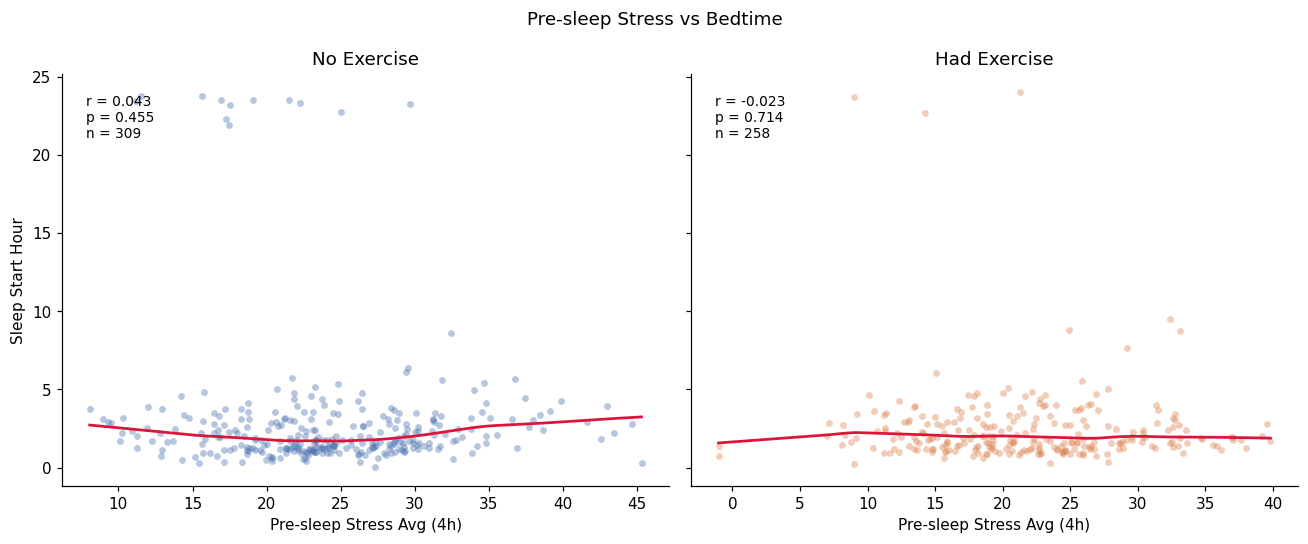

In [7]:
# --- 5.1 Scatter + LOWESS: stress vs bedtime, split by had_exercise ---
s3 = df.dropna(subset=["pre_sleep_stress_avg_4h", "sleep_start_hour"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
groups = [(False, "No Exercise", "#4C72B0"), (True, "Had Exercise", "#DD8452")]

for ax, (flag, label, col) in zip(axes, groups):
    sub = s3[s3["had_exercise"] == flag]
    ax.scatter(sub["pre_sleep_stress_avg_4h"], sub["sleep_start_hour"],
               alpha=0.4, s=20, color=col, linewidths=0)
    if len(sub) >= 10:
        r_c, p_c = stats.spearmanr(sub["pre_sleep_stress_avg_4h"],
                                   sub["sleep_start_hour"])
        sm = lowess(sub["sleep_start_hour"].values,
                    sub["pre_sleep_stress_avg_4h"].values, frac=0.45)
        ax.plot(sm[:, 0], sm[:, 1], color="crimson", lw=1.8)
        ax.text(0.04, 0.95, f"r = {r_c:.3f}\np = {p_c:.3f}\nn = {len(sub)}",
                transform=ax.transAxes, fontsize=9, va="top")
    ax.set_title(label)
    ax.set_xlabel("Pre-sleep Stress Avg (4h)")

axes[0].set_ylabel("Sleep Start Hour")
fig.suptitle("Pre-sleep Stress vs Bedtime", fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# --- 5.2 Raw Spearman r vs partial r controlling for had_exercise ---
import pingouin

s3_pg = df.dropna(subset=["pre_sleep_stress_avg_4h", "sleep_start_hour", "had_exercise"]).copy()
s3_pg["had_exercise_int"] = s3_pg["had_exercise"].astype(int)

raw_r, raw_p = stats.spearmanr(
    s3_pg["pre_sleep_stress_avg_4h"], s3_pg["sleep_start_hour"]
)

pcorr = pingouin.partial_corr(
    data=s3_pg,
    x="pre_sleep_stress_avg_4h",
    y="sleep_start_hour",
    covar="had_exercise_int",
    method="spearman",
)
partial_r = pcorr["r"].values[0]
partial_p = pcorr["p_val"].values[0]
print(f"Raw Spearman r       = {raw_r:.3f}, p = {raw_p:.4f}")
print(f"Partial r (ctrl had_exercise) = {partial_r:.3f}, p = {partial_p:.4f}")
print(f"\nInterpretation: {'stress→bedtime link persists after controlling for exercise' if partial_p < 0.05 else 'stress→bedtime link weakens after controlling for exercise'}")

Raw Spearman r       = 0.006, p = 0.8894
Partial r (ctrl had_exercise) = 0.007, p = 0.8662

Interpretation: stress→bedtime link weakens after controlling for exercise


---
## Section 4: Deep Sleep Onset Cascading (Night N → Night N+1)

**Hypothesis**: Taking a long time to reach first deep sleep on night N predicts worse sleep quality on night N+1 (cascading fatigue).

Analysis window: nights from 2025-10-01 onwards (144-night window with sleep architecture data).

Valid pairs (prev night → current score): n = 143
Spearman r = 0.066, p = 0.4349


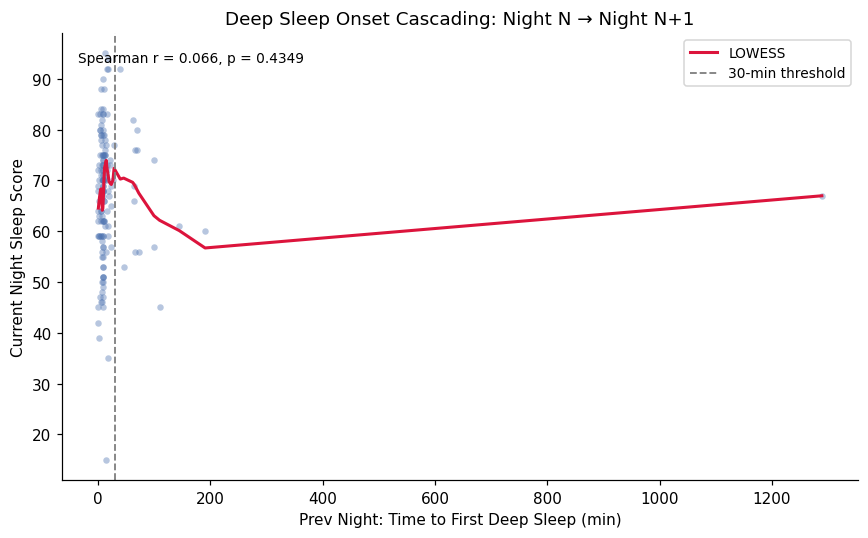

In [9]:
# --- 6.1 Shift time_to_first_deep_min by -1; correlate with next-night score ---
s4 = df[["day", "time_to_first_deep_min", "score"]].copy()
s4 = s4.sort_values("day").reset_index(drop=True)

# Shift: prev_time_to_first_deep = time_to_first_deep of the *previous* night
s4["prev_time_to_first_deep"] = s4["time_to_first_deep_min"].shift(1)

s4_clean = s4.dropna(subset=["prev_time_to_first_deep", "score"])
print(f"Valid pairs (prev night → current score): n = {len(s4_clean)}")

r_cascade, p_cascade = stats.spearmanr(
    s4_clean["prev_time_to_first_deep"], s4_clean["score"]
)
print(f"Spearman r = {r_cascade:.3f}, p = {p_cascade:.4f}")

# Scatter + LOWESS
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(s4_clean["prev_time_to_first_deep"], s4_clean["score"],
           alpha=0.4, s=18, color="#4C72B0", linewidths=0)
sm = lowess(s4_clean["score"].values, s4_clean["prev_time_to_first_deep"].values, frac=0.4)
ax.plot(sm[:, 0], sm[:, 1], color="crimson", lw=2, label="LOWESS")
ax.axvline(30, color="gray", lw=1.2, ls="--", label="30-min threshold")
ax.set_xlabel("Prev Night: Time to First Deep Sleep (min)")
ax.set_ylabel("Current Night Sleep Score")
ax.set_title("Deep Sleep Onset Cascading: Night N → Night N+1")
ax.text(0.02, 0.96, f"Spearman r = {r_cascade:.3f}, p = {p_cascade:.4f}",
        transform=ax.transAxes, fontsize=9, va="top")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# --- 6.2 Split: time_to_first_deep > 30 min vs <= 30 min ---
fast = s4_clean[s4_clean["prev_time_to_first_deep"] <= 30]
slow = s4_clean[s4_clean["prev_time_to_first_deep"] > 30]

mw_stat4, mw_p4 = stats.mannwhitneyu(
    fast["score"], slow["score"], alternative="greater"
)
n1_4, n2_4 = len(fast), len(slow)
rb_r4 = 1 - (2 * mw_stat4) / (n1_4 * n2_4)

summary4 = pd.DataFrame({
    "Group": ["<= 30 min to first deep", "> 30 min to first deep"],
    "n": [n1_4, n2_4],
    "Mean Next-Night Score": [fast["score"].mean(), slow["score"].mean()],
})
print(summary4.to_string(index=False, float_format="{:.2f}".format))
print(f"\nMann-Whitney: U={mw_stat4:.0f}, p={mw_p4:.4f}, rank-biserial r={rb_r4:.3f}")

                  Group   n  Mean Next-Night Score
<= 30 min to first deep 127                  67.23
 > 30 min to first deep  16                  66.88

Mann-Whitney: U=1070, p=0.3671, rank-biserial r=-0.053


---
## Section 5: Cardio vs Strength Workout Comparison

**Hypothesis**: Cardio workouts are associated with better next-night sleep than strength or rest days.

In [11]:
# --- 7.1 Group comparison table ---
# Include rest days as the baseline
s5 = df.copy()
s5["sport_group"] = s5["sport_category"].fillna("rest")

rows = []
rest_scores = s5[s5["sport_group"] == "rest"]["score"].dropna()

for grp in ["rest", "cardio", "strength", "mixed", "other"]:
    sub = s5[s5["sport_group"] == grp]["score"].dropna()
    dep = s5[s5["sport_group"] == grp]["is_deprived"].dropna()
    if grp == "rest" or len(sub) < 3:
        eff = float("nan")
        mw_p_grp = float("nan")
    else:
        mw_u, mw_p_grp = stats.mannwhitneyu(sub, rest_scores, alternative="two-sided")
        eff = 1 - (2 * mw_u) / (len(sub) * len(rest_scores))
    rows.append({
        "Sport Group": grp,
        "n": len(sub),
        "Mean Score": sub.mean(),
        "Median Score": sub.median(),
        "Deprivation Rate": dep.mean(),
        "Effect Size vs Rest (r)": eff,
    })

tbl5 = pd.DataFrame(rows)
print(tbl5.to_string(index=False, float_format="{:.3f}".format))

# Kruskal-Wallis across all groups
groups_kw = [
    s5[s5["sport_group"] == g]["score"].dropna()
    for g in ["rest", "cardio", "strength", "mixed"]
    if len(s5[s5["sport_group"] == g]["score"].dropna()) >= 3
]
kw_stat, kw_p = stats.kruskal(*groups_kw)
print(f"\nKruskal-Wallis: H={kw_stat:.2f}, p={kw_p:.4f}")

Sport Group   n  Mean Score  Median Score  Deprivation Rate  Effect Size vs Rest (r)
       rest 309      65.294        67.000             0.214                      NaN
     cardio 158      68.582        70.000             0.114                   -0.156
   strength  71      68.141        70.000             0.141                   -0.136
      mixed  26      71.269        74.000             0.138                   -0.350
      other   2      82.500        82.500             0.000                      NaN

Kruskal-Wallis: H=14.85, p=0.0019


/var/folders/3_/s_6vtgb51bz0pbkr9147ky_h0000gn/T/ipykernel_4796/1744888278.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=labels_bp, patch_artist=True, notch=True,


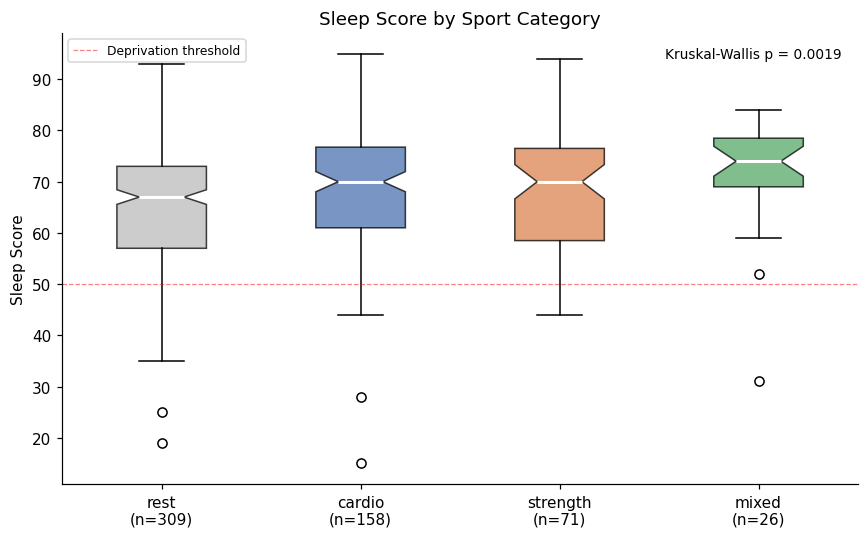

In [12]:
# --- 7.2 Box plot ---
sport_order = ["rest", "cardio", "strength", "mixed"]
data_bp = [
    s5[s5["sport_group"] == g]["score"].dropna().values
    for g in sport_order
]
labels_bp = [
    f"{g}\n(n={len(d)})" for g, d in zip(sport_order, data_bp)
]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_bp, labels=labels_bp, patch_artist=True, notch=True,
                medianprops={"color": "white", "linewidth": 2})
palette = ["#BBBBBB", "#4C72B0", "#DD8452", "#55A868"]
for patch, col in zip(bp["boxes"], palette):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)

ax.set_ylabel("Sleep Score")
ax.set_title("Sleep Score by Sport Category")
ax.text(0.98, 0.97, f"Kruskal-Wallis p = {kw_p:.4f}",
        transform=ax.transAxes, fontsize=9, ha="right", va="top")
ax.axhline(50, color="red", ls="--", lw=0.8, alpha=0.5, label="Deprivation threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 6: Daily Steps vs Sleep

**Note**: `calories_consumed` is entirely NULL in the database (Garmin only logs food intake when manually entered). Analysis uses `steps` only.

**Hypothesis**: Higher daily step count is associated with better sleep quality.

In [13]:
# --- 8.1 Spearman correlation table: steps × {score, total_sleep_hours} ---
print(f"steps non-null: {df['steps'].notna().sum()} / {len(df)}")
print(f"calories_consumed non-null: {df['calories_consumed'].notna().sum()} / {len(df)}  (all NULL — skipped)\n")

s6 = df.dropna(subset=["steps"]).copy()

corr_rows = []
for target in ["score", "total_sleep_hours"]:
    sub = s6.dropna(subset=[target])
    r_val, p_val = stats.spearmanr(sub["steps"], sub[target])
    corr_rows.append({"Feature": "steps", "Target": target,
                      "Spearman r": r_val, "p-value": p_val, "n": len(sub)})

print(pd.DataFrame(corr_rows).to_string(index=False, float_format="{:.4f}".format))

steps non-null: 588 / 601
calories_consumed non-null: 0 / 601  (all NULL — skipped)

Feature            Target  Spearman r  p-value   n
  steps             score      0.0226   0.5920 566
  steps total_sleep_hours      0.0819   0.0472 588


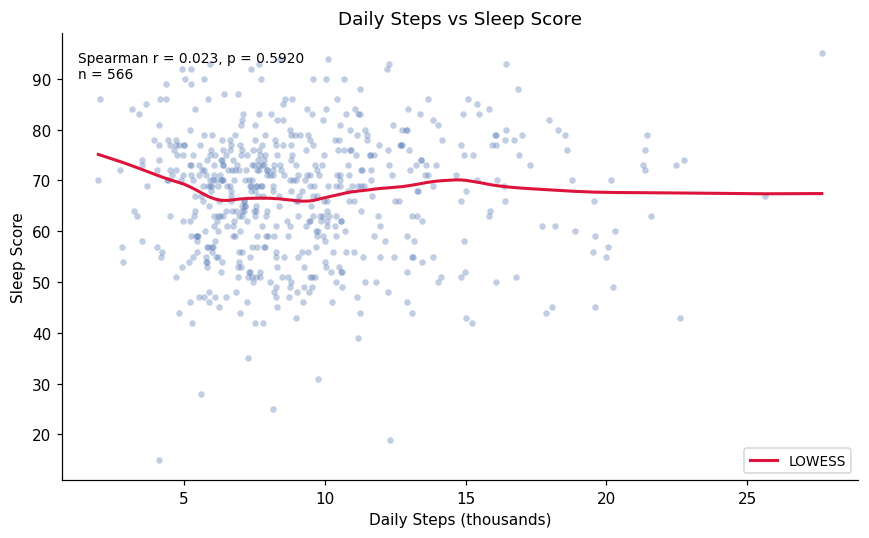

In [14]:
# --- 8.2 Scatter + LOWESS: steps vs score ---
s6_score = s6.dropna(subset=["score"])
r_step, p_step = stats.spearmanr(s6_score["steps"], s6_score["score"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(s6_score["steps"] / 1000, s6_score["score"],
           alpha=0.35, s=18, color="#4C72B0", linewidths=0)

xy6 = s6_score[["steps", "score"]].sort_values("steps")
sm6 = lowess(xy6["score"].values, xy6["steps"].values / 1000, frac=0.4)
ax.plot(sm6[:, 0], sm6[:, 1], color="crimson", lw=2, label="LOWESS")

ax.set_xlabel("Daily Steps (thousands)")
ax.set_ylabel("Sleep Score")
ax.set_title("Daily Steps vs Sleep Score")
ax.text(0.02, 0.96, f"Spearman r = {r_step:.3f}, p = {p_step:.4f}\nn = {len(s6_score)}",
        transform=ax.transAxes, fontsize=9, va="top")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## Summary

| Section | Hypothesis | Key Finding |
|---------|------------|-------------|
| 1 | 3 AM bedtime cliff-edge | See Section 1 output |
| 2 | Vigorous ratio > sport label | See Section 2 output |
| 3 | Stress → later bedtime | See Section 3 output |
| 4 | Deep sleep onset cascading | See Section 4 output |
| 5 | Cardio > strength for sleep | See Section 5 output |
| 6 | Steps → better sleep | See Section 6 output |